#Data representation and interaction 
##The pandas dataframe: storing and manipulating data from the pandas module (python library for tabular data)  

In [121]:
#load the pandas library 
import pandas
#download the csv file from the tutorial page, upload then run this to "read" the file
data = pandas.read_csv('brain_size.csv', sep=';', na_values=".")
#show what is in the csv file as data 
data
#create an array from the data table 
import numpy as np
#loads numpy and nickname it np 
t = np.linspace(-6, 6, 20)
#creates 20 evenly spaced numbers from -6 to 6 on the x axis 
sin_t = np.sin(t)
#sin every t(x-axis) value 
cos_t = np.cos(t)
#take the cos of every t value 
pandas.DataFrame({'t': t, 'sin': sin_t, 'cos': cos_t})  
#create data table from t, sin(t), cos(t) 
data.shape 
#shows how the data is structured 
data.columns
#shows the data table is separated by columns 
print(data['Gender'])
#shows all values in the "Gender" column 
data[data['Gender'] == 'Female']['VIQ'].mean()
#takes all female values from the gender row and viq column, and shows the mean of those values 
pandas.DataFrame.describe(data)
#gives overview of important features of the dataset 

groupby_gender = data.groupby('Gender')
for gender, value in groupby_gender['VIQ']:
    print((gender, value.mean()))
#groups the data based on male vs female 
#shows the mean viq value from each group
groupby_gender.mean()
#shows all the mean values from each category in the gender groups 

0     Female
1       Male
2       Male
3       Male
4     Female
5     Female
6     Female
7     Female
8       Male
9       Male
10    Female
11      Male
12      Male
13    Female
14    Female
15    Female
16    Female
17      Male
18    Female
19      Male
20      Male
21      Male
22    Female
23      Male
24    Female
25      Male
26    Female
27      Male
28    Female
29    Female
30    Female
31      Male
32      Male
33      Male
34    Female
35    Female
36      Male
37    Female
38      Male
39      Male
Name: Gender, dtype: object
('Female', np.float64(109.45))
('Male', np.float64(115.25))


,Unnamed: 0,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,,
Female,19.65,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,21.35,115.0,115.25,111.60,166.444444,71.431579,954855.4


###Exercise: What is the mean value for VIQ for the full population? How many males/females were included in this study? What is the average value of MRI counts expressed in log units, for males and females?

In [122]:
#What is the mean value for VIQ for the full population?
data['VIQ'].mean()
#How many males/females were included in this study?
groupby_gender = data.groupby('Gender')
groupby_gender.size()
#What is the average value of MRI counts expressed in log units, for males and females?
for gender, value in groupby_gender['MRI_Count']:
    print((gender, np.log(value).mean()))

('Female', np.float64(13.665829512882837))
('Male', np.float64(13.767731054975144))


##Plotting data with pandas 

array([[<Axes: xlabel='PIQ', ylabel='PIQ'>,
        <Axes: xlabel='VIQ', ylabel='PIQ'>,
        <Axes: xlabel='FSIQ', ylabel='PIQ'>],
       [<Axes: xlabel='PIQ', ylabel='VIQ'>,
        <Axes: xlabel='VIQ', ylabel='VIQ'>,
        <Axes: xlabel='FSIQ', ylabel='VIQ'>],
       [<Axes: xlabel='PIQ', ylabel='FSIQ'>,
        <Axes: xlabel='VIQ', ylabel='FSIQ'>,
        <Axes: xlabel='FSIQ', ylabel='FSIQ'>]], dtype=object)

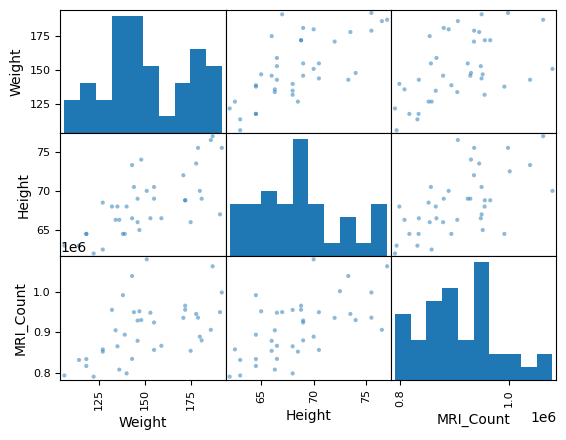

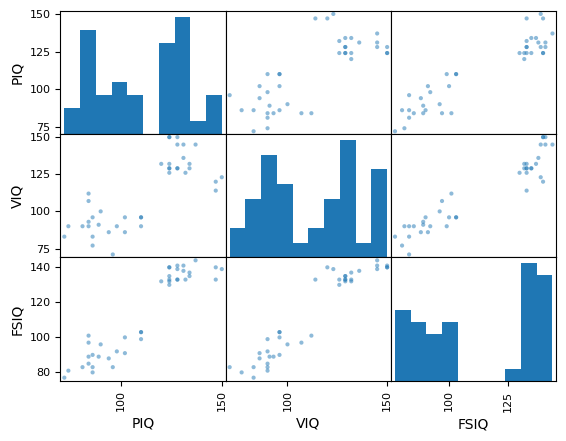

In [123]:
from pandas import plotting
#imports plotting tools from the pandas library 
plotting.scatter_matrix(data[['Weight', 'Height', 'MRI_Count']])   
#makes a matrix with three columns: weight, height, MRI count 
plotting.scatter_matrix(data[['PIQ', 'VIQ', 'FSIQ']]) 
#makes a matrix with three columns for the IQ scoress: PIQ, VIQ, FSIQ 

###Exercise: Plot the scatter matrix for males only, and for females only. Do the 2 sub-populations correspond to gender?

array([[<Axes: xlabel='PIQ', ylabel='PIQ'>,
        <Axes: xlabel='VIQ', ylabel='PIQ'>,
        <Axes: xlabel='FSIQ', ylabel='PIQ'>],
       [<Axes: xlabel='PIQ', ylabel='VIQ'>,
        <Axes: xlabel='VIQ', ylabel='VIQ'>,
        <Axes: xlabel='FSIQ', ylabel='VIQ'>],
       [<Axes: xlabel='PIQ', ylabel='FSIQ'>,
        <Axes: xlabel='VIQ', ylabel='FSIQ'>,
        <Axes: xlabel='FSIQ', ylabel='FSIQ'>]], dtype=object)

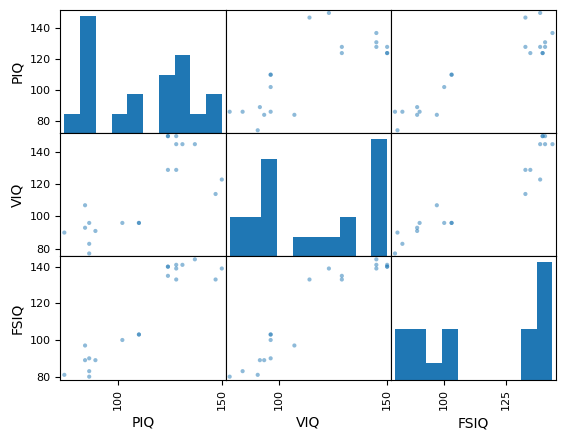

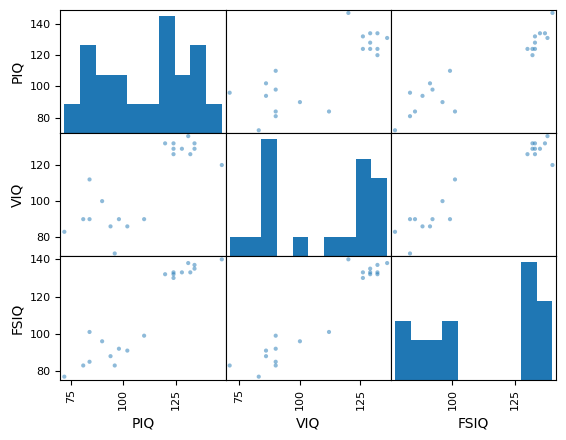

In [124]:
data = pandas.read_csv('brain_size.csv', sep=';', na_values='.')
male_data = data[data['Gender'] == 'Male']
plotting.scatter_matrix(male_data[['PIQ', 'VIQ', 'FSIQ']])
#from the data in the male rows, plot the IQ measures against each other 
female_data = data[data['Gender'] == 'Female']
plotting.scatter_matrix(female_data[['PIQ', 'VIQ', 'FSIQ']])
#from the data in the female rows, plot the IQ values against each other 

#IQ groupings appear to show simillar clustering within the group as within the whole population; therefore, this is not based on gender. 

#Hypothesis testing: Comparing two groups 

In [125]:
from scipy import stats
stats.ttest_1samp(data['VIQ'], 0)   
#runs a one-sample t-test (i.e. is the average VIQ different from 0) 
female_viq = data[data['Gender'] == 'Female']['VIQ']
#creates series of VIQ scores for females only 
male_viq = data[data['Gender'] == 'Male']['VIQ']
stats.ttest_ind(female_viq, male_viq)   
#runs two-samplle t-test comparing female and male VIQ scores 
stats.ttest_ind(data['FSIQ'], data['PIQ']) 
#runs an independent two-sample t-test on FSIQ and PIQ scores 
stats.ttest_rel(data['FSIQ'], data['PIQ']) 
#these two values are repeated measures (from the same individual), so a paired t test is necessary
stats.ttest_1samp(data['FSIQ'] - data['PIQ'], 0) 
#a one sample t test to test if an individual's FSSIQ-PIQ difference is 0
stats.wilcoxon(data['FSIQ'], data['PIQ']) 
#run this to test wilcoxon test, which does not assume gausssian error 

WilcoxonResult(statistic=np.float64(274.5), pvalue=np.float64(0.10659492713506856))

###Exercise 3: Test the difference between weights in males and females.
Use non parametric statistics to test the difference between VIQ in males and females.

In [126]:
female_weight = data[data['Gender'] == 'Female']['Weight']
male_weight = data[data['Gender'] == 'Male']['Weight']
#get weights by gender 
stats.ttest_ind(female_weight, male_weight)
#independent t test since weights are from different people 
stats.ttest_ind(female_weight, male_weight, nan_policy='omit')
#one weight value is missing so nan_policy='omit' will exclude thiss value and prevent error

TtestResult(statistic=np.float64(-4.870950921940696), pvalue=np.float64(2.227293018362118e-05), df=np.float64(36.0))

#Part 3: Linear models, multiple factors, and analysis of variance 

In [127]:
import numpy as np
x = np.linspace(-5, 5, 20)
np.random.seed(1)
#this sets the random number generator to 1; now the random numbers are reproduciblle and re-running the program willl give the same resullts 
y = -5 + 3*x + 4 * np.random.normal(size=x.shape) 
#this creates noise in the model; the points won't all lie perfectly on the line (thus making it more real) 
data = pandas.DataFrame({'x': x, 'y': y})
#this turns the arrays into a pandas table, with x and y columns 
%pip install statsmodels
#this installs statsmodels to prevent error 
from statsmodels.formula.api import ols
#imports ordinary least squares, which is a way to fit a straight line to make prediction errors as small as possible 
model = ols("y ~ x", data).fit()
#this fits the linear regression predicting y from x 
print(model.summary())

Note: you may need to restart the kernel to use updated packages.
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     74.03
Date:                Sun, 26 Jul 2026   Prob (F-statistic):           8.56e-08
Time:                        23:23:22   Log-Likelihood:                -57.988
No. Observations:                  20   AIC:                             120.0
Df Residuals:                      18   BIC:                             122.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

###Exercise: Retrieve the estimated parameters from the model above.

In [128]:
model.params
#the estimated coefficients from the fitted model
data = pandas.read_csv('brain_size.csv', sep=';', na_values=".")
model = ols("VIQ ~ Gender + 1", data).fit()
#fits the linear model to determine if VIQ differs by gender 
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Sun, 26 Jul 2026   Prob (F-statistic):              0.445
Time:                        23:23:22   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.

Categorical variables: comparing groups and multiple categories 

##Multiple Regression (including multiple factors) 

In [129]:
data = pandas.read_csv('iris.csv')
model = ols('sepal_width ~ name + petal_length', data).fit()
print(model.summary())  

                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Sun, 26 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        23:23:22   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.9813      0

##Post-hoc tests: analysis of variance (ANOVA) 

In [130]:
print(model.f_test([0, 1, -1, 0])) 
#builds a combination of the coefficients 0, 1, -1 to test whether versicolor and virginica differ in sepal width after accounting for petal length  

<F test: F=3.245335346574177, p=0.0736905878170114, df_denom=146, df_num=1>


Exercise: Going back to the brain size + IQ data, test if the VIQ of male and female are different after removing the effect of brain size, height and weight.



In [131]:
data = pandas.read_csv('brain_size.csv', sep=';', na_values='.')
#reload the brain_size.csv file since it was overwritten by iris data 
model = ols('VIQ ~ Gender + MRI_Count + Height + Weight', data).fit()
#using ols to fit linear model and minimize  squared prediction  errors 
#after accounting for MRI_count,  height,  weight, do males and females differ in VIQ?
print(model.summary())
#shows the results 

                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     2.733
Date:                Sun, 26 Jul 2026   Prob (F-statistic):             0.0455
Time:                        23:23:22   Log-Likelihood:                -167.03
No. Observations:                  38   AIC:                             344.1
Df Residuals:                      33   BIC:                             352.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        169.7719     90.054      1.

In [132]:
#using the F test instead: 
print(model.f_test('Gender[T.Male] = 0'))

<F test: F=0.8698460744965469, p=0.35777194392092415, df_denom=33, df_num=1>


In [133]:
#not statistically significant!  

#Seaborn for statistical  exploration 

##Pairplot: scatter matrices 

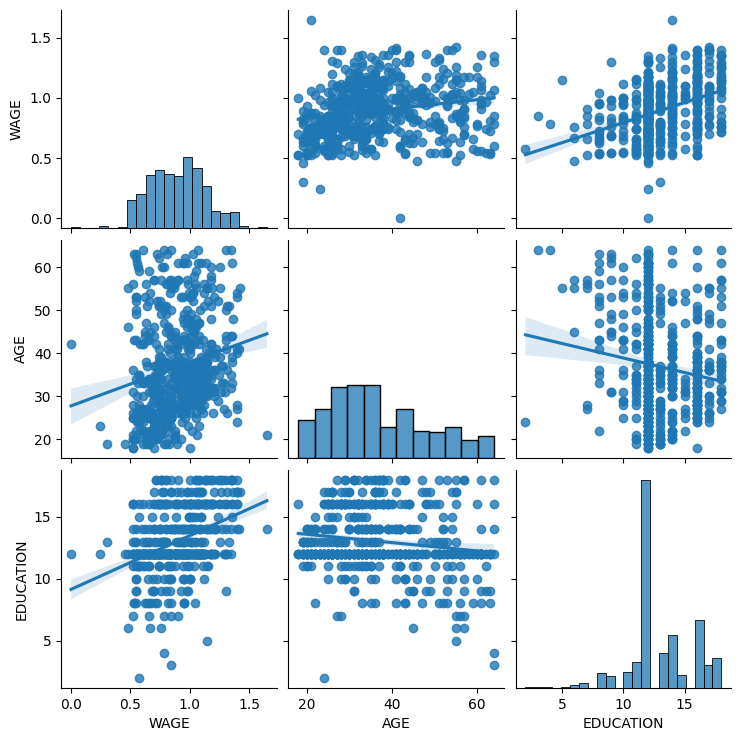

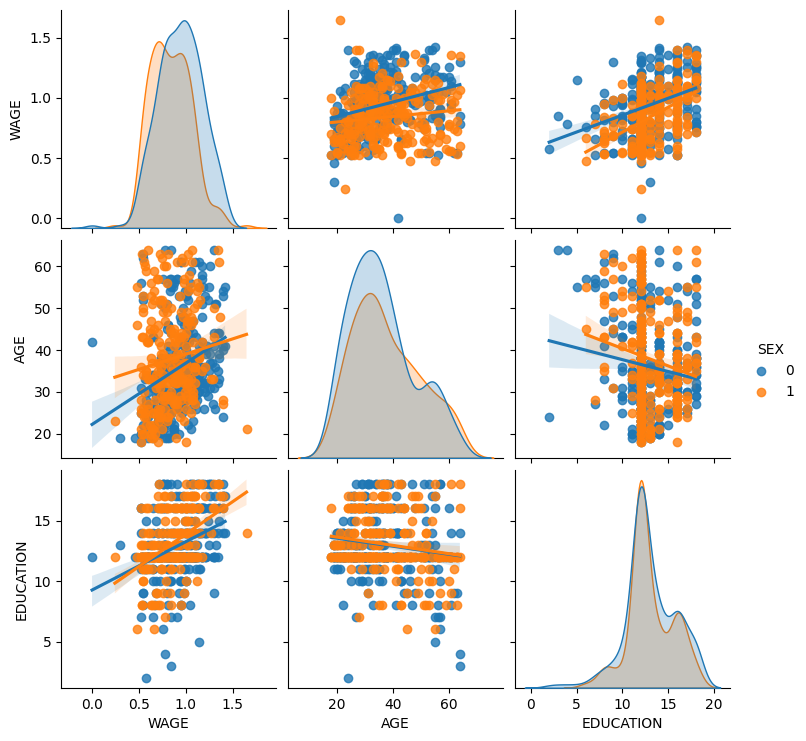

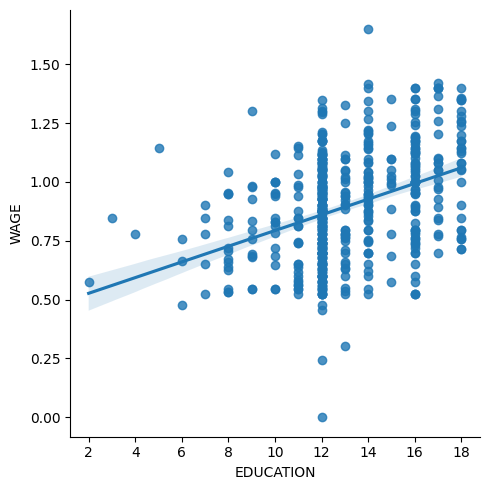

In [134]:
#download the dataset and save as wagess.txt
import seaborn
import numpy as np
#seaborn is a python library for statistical plotting 
#importing necessary to make plots 
names = [
    'EDUCATION: Number of years of education',
    'SOUTH: 1=Person lives in South, 0=Person lives elsewhere',
    'SEX: 1=Female, 0=Male',
    'EXPERIENCE: Number of years of work experience',
    'UNION: 1=Union member, 0=Not union member',
    'WAGE: Wage (dollars per hour)',
    'AGE: years',
    'RACE: 1=Other, 2=Hispanic, 3=White',
    'OCCUPATION: 1=Management, 2=Sales, 3=Clerical, 4=Service, 5=Professional, 6=Other',
    'SECTOR: 0=Other, 1=Manufacturing, 2=Construction',
    'MARR: 0=Unmarried,  1=Married',
]
#name the currently blank columns so pandas can read 
short_names = [n.split(':')[0] for n in names]
#creates shortened column names 
data = pandas.read_csv(
    'wages.txt',
    sep=None,
    header=None,
    names=names,
    skiprows=27,
    skipfooter=6,
    engine='python'
)
#seaborn needs a pandas dataframe to work. 
#numbers are separated by spacesss, not commas
#the first row is not the column names; pandas will treat as so without header=none 
#skiprows=27 to skip the 27 rowss with text explanations 
data.columns = short_names
#renames the columns of the dataframe to the short names 
data['WAGE'] = np.log10(data['WAGE'])
#transforms wage to a log value 
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                 kind='reg')
#makes scatterplot matrix of wage, age, and education with regression lines 
seaborn.pairplot(data, vars=['WAGE', 'AGE', 'EDUCATION'],
                 kind='reg', hue='SEX') 
#makes scatterplots of wage, age and education separated by sex 
from matplotlib import pyplot as plt
#imports pyplot from matplotlib to use these settings when generating the plots 
plt.rcdefaults()
#restoring original defaults 
seaborn.lmplot(y='WAGE', x='EDUCATION', data=data) 
#makes a  scatterplot of education vss  wage with overlayed regresssion line 

#Implot: plotting a univariate regression

#Testing for interactions 

In [135]:
import statsmodels.formula.api as sm
#loads the statsmodels library
#nicknames it sm 
result = sm.ols(formula='WAGE ~ EDUCATION + SEX + EDUCATION * SEX',
                data=data).fit() 
#fits a linear model that tests whether the relationship between education and wage is different between the sexes (i.e. do they interact?) 
print(result.summary())
#shows the results 

                            OLS Regression Results                            
Dep. Variable:                   WAGE   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     43.72
Date:                Sun, 26 Jul 2026   Prob (F-statistic):           2.94e-25
Time:                        23:23:26   Log-Likelihood:                 88.503
No. Observations:                 534   AIC:                            -169.0
Df Residuals:                     530   BIC:                            -151.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.5748      0.058      9.861